In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
cwd = os.getcwd()
print(cwd)

d:\IEEE CIS Fraud Detection


# Data Loading and EDA

In [3]:
data_path = os.path.join(cwd, 'dataset')

### About the dataset
The data is broken into two files identity and transaction, which are joined by TransactionID. Not all transactions have corresponding identity information.

*Categorical Features - Transaction*
* ProductCD
* card1 - card6
* addr1, addr2
* P_emaildomain
* R_emaildomain
* M1 - M9

*Categorical Features - Identity*
* DeviceType
* DeviceInfo
* id_12 - id_38

The TransactionDT feature is a timedelta from a given reference datetime (not an actual timestamp).

For further details about the dataset: https://www.kaggle.com/c/ieee-fraud-detection/discussion/101203

In [4]:
df = pd.read_csv(os.path.join(data_path, "train_merged.csv"))

In [5]:
print("the shape of df is:", df.shape)

the shape of df is: (590540, 434)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


In [7]:
df.head(2)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df.drop(columns=['TransactionID'], inplace=True) #transaction id will be of no use to learn any pattern.

In [9]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [10]:
df['TransactionAmt'].corr(df['isFraud'])

0.011319825333215112

<Axes: >

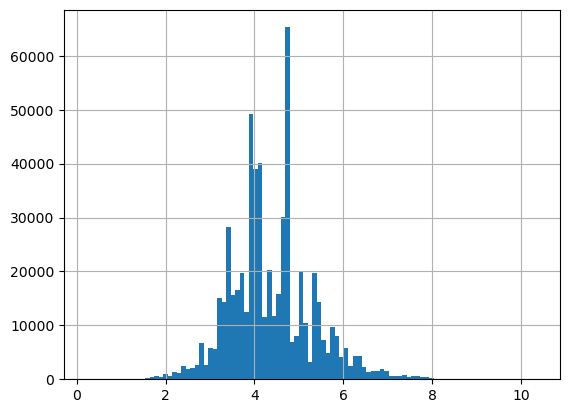

In [11]:
np.log1p(df["TransactionAmt"]).hist(bins = 100)

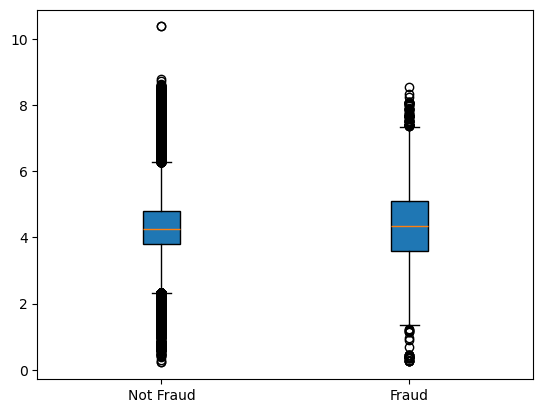

In [12]:
plt.boxplot([np.log1p(df[df['isFraud']==0]['TransactionAmt']), np.log1p(df[df['isFraud']==1]['TransactionAmt'])],
            labels=['Not Fraud', 'Fraud'],
            #notch=True,
            patch_artist=True)
plt.show()

In [13]:
print("the number of columns in df that have more than 75% null values is:", df.isna().sum()[df.isna().sum().values > 75*df.shape[0]/100].shape[0])

the number of columns in df that have more than 75% null values is: 208


It suggests that there are a lot of columns with high proportion of missing values. Let's do some further analysis to decide what to do with these columns.

In [14]:
temp = df.isna().sum()[df.isna().sum().values > 75*df.shape[0]/100].index

In [15]:
dict = {}
for x in temp:
    if df[x].dtype != object and df[x].dtype != str:
        dict[x] = df['isFraud'].corr(df[x])

In [16]:
max(dict.values())

0.3830597510206028

In [17]:
min(dict.values())

-0.14263641015850026

So there do are some columns which have correlation > 0.30 and have more than 75% missing values.

In [18]:
count = 0
for x in dict.keys():
    if dict[x] > 0.20:
        print(x, dict[x])
        count+=1
print(count)

V147 0.2428943745397724
V148 0.22889104114794714
V149 0.2732821052990537
V154 0.2069584335723
V155 0.23419901739686866
V156 0.2759520895145737
V157 0.2348663695600234
V158 0.2780662447880996
V170 0.24979447724564624
V171 0.2165084943537853
V188 0.30358227133771953
V189 0.3082194603691243
V190 0.2051483549916036
V199 0.2310243115077046
V200 0.3187825140584449
V201 0.3280050345981545
V228 0.26886098278184184
V230 0.23173981248706324
V242 0.360590490265958
V243 0.21023818475957995
V244 0.3641291589611914
V246 0.36687769909837276
V257 0.3830597510206028
V258 0.29715149798963714
24


Although 208 features contain more than 75% missing values, several of these features exhibit substantial correlation with the target variable. Therefore, these features will not be removed solely on the basis of missingness at this stage. Their predictive value will be evaluated further during feature selection.

In [19]:
df.groupby(df["V257"].isna())["isFraud"].mean()

V257
False    0.078142
True     0.022758
Name: isFraud, dtype: float64

Feature V257 exhibits a correlation of 0.38 with the target variable despite having more than 75% missing values. Furthermore, transactions for which V257 is present have a fraud rate of 7.81%, compared to 2.28% when the feature is missing. This suggests that both the feature value and its missingness may contain predictive information.

In [20]:
df.V257.isna().mean()

0.7791343516103905

now we calculate the similar metrics for all the columns of df.

In [21]:
missing_pct = df.isna().mean()*100
fraud_when_present = []
fraud_when_absent = []
for x in df.columns:
    grouped = df.groupby(df[x].isna())['isFraud'].mean()
    fraud_when_present.append(grouped.get(False, np.nan))
    fraud_when_absent.append(grouped.get(True, np.nan))
missing_summary = pd.DataFrame({#'feature name':df.columns,
                                'missing_pct': missing_pct,
                                'ratio of fraud when present': fraud_when_present,
                                'ratio of fraud when absent': fraud_when_absent}).sort_values('missing_pct', ascending=False)

missing_summary["ratio_diff"] = (missing_summary["ratio of fraud when present"] - missing_summary["ratio of fraud when absent"]).abs()
#to filter out those columns that does not give sufficient differnce.

In [146]:
missing_summary.head(20)

,missing_pct,ratio of fraud when present,ratio of fraud when absent,ratio_diff
id_24,99.196159,0.084685,0.034587,0.050098
id_25,99.130965,0.081255,0.034584,0.046670
id_08,99.127070,0.082638,0.034570,0.048068
id_07,99.127070,0.082638,0.034570,0.048068
id_21,99.126393,0.082574,0.034571,0.048003
id_26,99.125715,0.082316,0.034573,0.047744
id_27,99.124699,0.082414,0.034571,0.047843
id_23,99.124699,0.082414,0.034571,0.047843
id_22,99.124699,0.082414,0.034571,0.047843
dist2,93.628374,0.099158,0.030623,0.068534


# Data Preprocessing

Based on the results of above table, I think any feature with missing_pct>75%(high proportion of missing values) and ratio_diff<0.02(meaning the missingness or the presence of the feature is not meaningful) should be dropped instantly.

In [23]:
redundant_columns = missing_summary[(missing_summary['missing_pct']>75) & (missing_summary['ratio_diff']<0.02)].index.tolist()

In [24]:
print("Number of redundant columns are:", len(redundant_columns))

Number of redundant columns are: 52


In [25]:
redundant_columns[2:7]

['id_32', 'id_34', 'id_14', 'V141', 'V157']

since the redundant columns are highly missing in values(>75%) and their missingness is also not informative to detect a fraud transaction(the ratio diffrenece is < 2%), I think it will be better to drop them from the dataset.

In [26]:
df.drop(columns=redundant_columns, inplace=True)

In [27]:
print("After dropping the redundant columns, the remaining number of columns is:", df.shape[1])

After dropping the redundant columns, the remaining number of columns is: 381


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 381 entries, isFraud to DeviceInfo
dtypes: float64(350), int64(3), object(28)
memory usage: 1.7+ GB


So there are 28 object and 353 numeric columns remaining after removing the redundant columns.

In [30]:
df.duplicated().sum()

0

In [29]:
missing_pct1 = df.isna().mean()*100

missing_pct1.sort_values(ascending=False).head(15)

id_24    99.196159
id_25    99.130965
id_08    99.127070
id_07    99.127070
id_21    99.126393
id_26    99.125715
id_22    99.124699
id_23    99.124699
id_27    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
dtype: float64

### Null value imputation strategy:
If a column is categorical:
* Check if it has >95% missing values, then fill with 'missing'
* if it has <95% missing values but the proportions of fraud when it is missing vs when it is not missing is signigicant(let's say >2%), then fill with 'missing'.
* otherwise fill with the mode of the column.

If a columns is non-categorical:
* fill it with the median(as median is robust to outliers and in fraud detection, there is high chances of outliers affecting the dataset and the results).

In [30]:
cat_cols = []

In [31]:
for x in df.columns:
    if x.startswith(('Product', 'card', 'addr', 'P_email', 'R_email', 'M')):
        print(x)
        cat_cols.append(x)

ProductCD
card1
card2
card3
card4
card5
card6
addr1
addr2
P_emaildomain
R_emaildomain
M1
M2
M3
M4
M5
M6
M7
M8
M9


In [32]:
for x in df.columns:
    if x.startswith(('Device', 'id')):
        print(x)
        cat_cols.append(x)

id_01
id_02
id_03
id_04
id_05
id_06
id_07
id_08
id_09
id_10
id_11
id_12
id_13
id_15
id_16
id_17
id_18
id_19
id_20
id_21
id_22
id_23
id_24
id_25
id_26
id_27
id_28
id_29
id_31
id_35
id_36
id_37
id_38
DeviceType
DeviceInfo


apart from id_14, 30, 32, 33, 34 all other categorical columns from the original dataset are present.

In [35]:
df['ProductCD'].unique()

array(['W', 'H', 'C', 'S', 'R'], dtype=object)

In [36]:
print(df['card1'].dtype)
print(df['card2'].dtype)
print(df['card3'].dtype)
print(df['card4'].dtype)
print(df['card5'].dtype)
print(df['card6'].dtype)

int64
float64
float64
object
float64
object


In [37]:
print(df['card1'].nunique())
print(df['card2'].nunique())
print(df['card3'].nunique())
print(df['card4'].nunique())
print(df['card5'].nunique())
print(df['card6'].nunique())

13553
500
114
4
119
4


In [38]:
df['card4'].unique()

array(['discover', 'mastercard', 'visa', 'american express', nan],
      dtype=object)

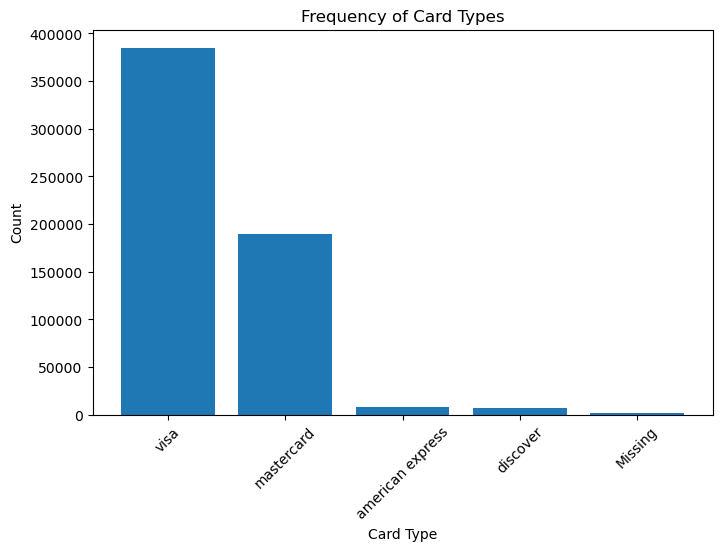

In [40]:
card4_counts = df["card4"].fillna("Missing").value_counts()

plt.figure(figsize=(8,5))
plt.bar(card4_counts.index, card4_counts.values)
plt.title("Frequency of Card Types")
plt.xlabel("Card Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

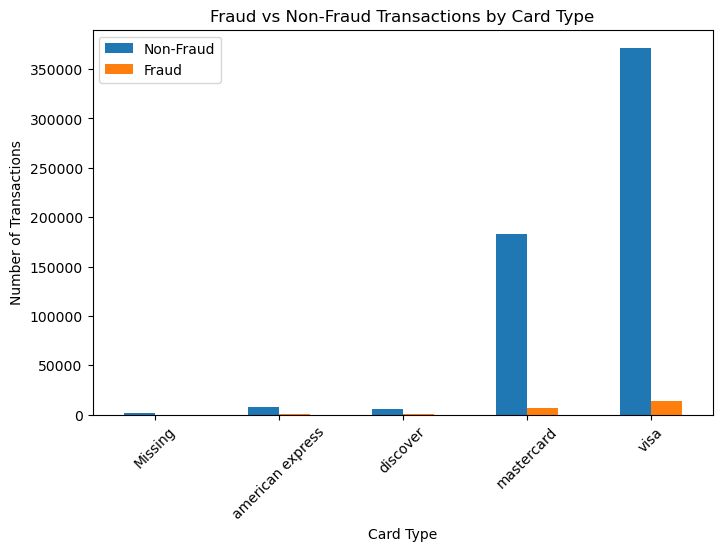

In [44]:
temp = (
    df.assign(card4=df["card4"].fillna("Missing"))
      .groupby(["card4", "isFraud"])
      .size()
      .unstack(fill_value=0)
)

temp.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fraud vs Non-Fraud Transactions by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.legend(["Non-Fraud", "Fraud"])
plt.show()

In [45]:
df['card6'].unique()

array(['credit', 'debit', nan, 'debit or credit', 'charge card'],
      dtype=object)

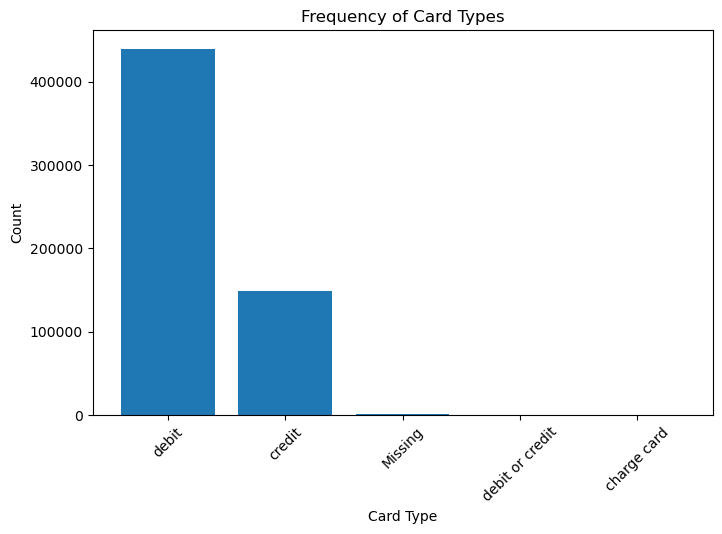

In [46]:
card4_counts = df["card6"].fillna("Missing").value_counts()

plt.figure(figsize=(8,5))
plt.bar(card4_counts.index, card4_counts.values)
plt.title("Frequency of Card Types")
plt.xlabel("Card Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

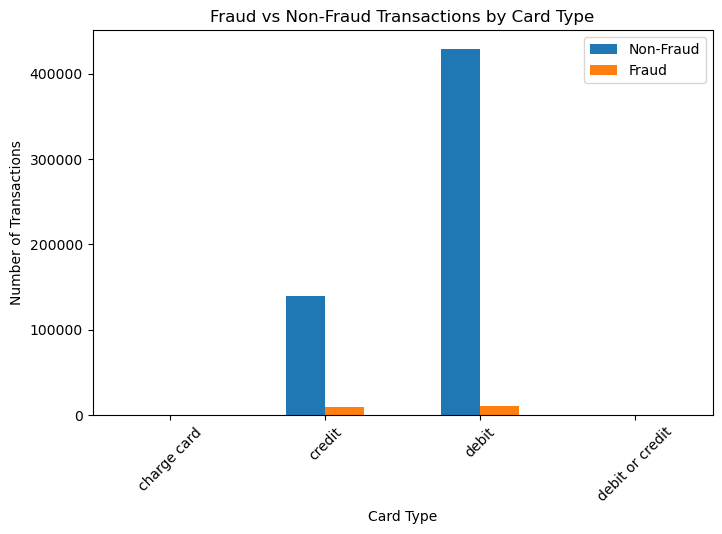

In [47]:
temp = (
    df.assign(card4=df["card6"].fillna("Missing"))
      .groupby(["card6", "isFraud"])
      .size()
      .unstack(fill_value=0)
)

temp.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fraud vs Non-Fraud Transactions by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.legend(["Non-Fraud", "Fraud"])
plt.show()

Now we move ahead with the train test split and then we will use the X_train to compute our metrics again to fill the null values separately so that there is no data leakage from the validation set.

In [48]:
from sklearn.model_selection import train_test_split

X = df.drop('isFraud', axis=1)
y = df['isFraud']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=27, stratify=y)

In [49]:
import gc

del X
del y

gc.collect()

0

In [50]:
print(y_train.mean())
print(y_val.mean())

0.03498916246147594
0.0349933958749619


In [51]:
df['TransactionDT']

0            86400
1            86401
2            86469
3            86499
4            86506
            ...   
590535    15811047
590536    15811049
590537    15811079
590538    15811088
590539    15811131
Name: TransactionDT, Length: 590540, dtype: int64

In [52]:
# calculation of missing_summary using only X_train and y_train to avoid data leakage

train_df = pd.concat([X_train, y_train], axis=1)
missing_pct_train = train_df.isna().mean()*100
fraud_when_present = []
fraud_when_absent = []
for x in train_df.columns:
    grouped = train_df.groupby(train_df[x].isna())['isFraud'].mean()
    fraud_when_present.append(grouped.get(False, np.nan))
    fraud_when_absent.append(grouped.get(True, np.nan))
missing_summary_train = pd.DataFrame({'missing_pct': missing_pct_train,
                                'ratio of fraud when present': fraud_when_present,
                                'ratio of fraud when absent': fraud_when_absent}).sort_values('missing_pct', ascending=False)

missing_summary_train["ratio_diff"] = (missing_summary_train["ratio of fraud when present"] - missing_summary_train["ratio of fraud when absent"]).abs()
#to filter out those columns that does not give sufficient differnce.

In [53]:
def na_value_impute(df, cat_cols):
    for column in df.columns:
        if column in cat_cols:
            if (df[column].isna().mean()>=0.95) or ((df[column].isna().mean()<0.95) and (missing_summary_train.loc[column, 'ratio_diff']>0.02)):
                if(df[column].dtype == object):
                    df[column] = df[column].fillna('missing')
                else:
                    df[column] = df[column].fillna(-999)
            else:
                df[column] = df[column].fillna(df[column].mode()[0])
        else:
            df[column] = df[column].fillna(df[column].median())

In [54]:
missing_summary_train.head(2)

,missing_pct,ratio of fraud when present,ratio of fraud when absent,ratio_diff
id_24,99.197768,0.084960,0.034585,0.050375
id_25,99.130034,0.080779,0.034587,0.046191


In [55]:
na_value_impute(X_train, cat_cols)
na_value_impute(X_val, cat_cols)

In [56]:
print(X_train.isna().sum().max())
print(X_val.isna().sum().max())

0
0


In [57]:
for column in df.columns:
    if (column not in cat_cols) and (df[column].dtype != int) and (df[column].dtype != float) and (df[column].dtype != np.int64):
        print(column)
print('*')

*


implies there are no other object type features other than any present in cat_cols

In [58]:
object_cols = X_train.select_dtypes(include='object').columns.tolist()

In [59]:
for col in object_cols:
    print(col, X_train[col].nunique())

ProductCD 5
card4 4
card6 4
P_emaildomain 59
R_emaildomain 61
M1 3
M2 3
M3 3
M4 4
M5 2
M6 3
M7 3
M8 3
M9 3
id_12 3
id_15 4
id_16 3
id_23 4
id_27 3
id_28 3
id_29 3
id_31 127
id_35 3
id_36 3
id_37 3
id_38 3
DeviceType 3
DeviceInfo 1691


hence we will do frequency encodings for the columns id_31 and DeviceInfo(because they have very high number of categories), and will do one-hot encoding for the rest of the categorical columns.

In [60]:
col_with_low_cardinality = [column for column in object_cols if X_train[column].nunique()<=65]
col_with_high_cardinality = [column for column in object_cols if X_train[column].nunique()>65]

In [61]:
freq_map_id31 = X_train['id_31'].value_counts(normalize = True)
freq_map_DeviceInfo = X_train['DeviceInfo'].value_counts(normalize = True)

In [62]:
def encoding_object_cols(df, col_with_low_cardinality, freq_map_id31, freq_map_DeviceInfo):
    df = pd.get_dummies(df, columns=col_with_low_cardinality, drop_first=True)
    df['id_31'] = df['id_31'].map(freq_map_id31).fillna(0)
    df['DeviceInfo'] = df['DeviceInfo'].map(freq_map_DeviceInfo).fillna(0)

    return df

In [63]:
X_train = encoding_object_cols(X_train, col_with_low_cardinality, freq_map_id31, freq_map_DeviceInfo)
X_val = encoding_object_cols(X_val, col_with_low_cardinality, freq_map_id31, freq_map_DeviceInfo)

Let's do some sanity checks and then move ahead to model selection.

In [64]:
print(X_train.shape)

(472432, 526)


In [65]:
print(X_val.shape)

(118108, 525)


In [66]:
set(X_train.columns) - set(X_val.columns)

{'R_emaildomain_netzero.net'}

In [67]:
X_train, X_val = X_train.align(
    X_val,
    join='left',
    axis=1,
    fill_value=0
)

In [68]:
print(X_train.shape)
print(X_val.shape)

(472432, 526)
(118108, 526)


In [69]:
set(X_train.columns) - set(X_val.columns)

set()

In [70]:
set(X_val.columns) - set(X_train.columns)

set()

In [71]:
print(X_train.isna().sum().sum())
print(X_val.isna().sum().sum())

0
0


In [72]:
print(y_train.shape)
print(y_val.shape)

(472432,)
(118108,)


# Logistic Regression(Baseline model)

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [74]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [75]:
model_lr = LogisticRegression(max_iter=3000,
                              random_state=27)

In [76]:
model_lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=3000, random_state=27)

In [77]:
y_pred_lr = model_lr.predict(X_val_scaled)
y_prob_lr = model_lr.predict_proba(X_val_scaled)[:, 1]

In [82]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

def evaluate_model(model_name, y_true, y_pred, y_prob):

    print("Evaluation summary for", model_name)
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion matrix:\n",cm)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    print("\nAccuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC-AUC  :", auc)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    return {"Model": model_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC-AUC": auc,
            "TN": cm[0][0],
            "FP": cm[0][1],
            "FN": cm[1][1],
            "TP": cm[1][0]}

Evaluation summary for Logistic Regression

Confusion matrix:
 [[113744    231]
 [  3060   1073]]

Accuracy : 0.9721356724353981
Precision: 0.8228527607361963
Recall   : 0.25961771110573434
F1 Score : 0.39470296119183373
ROC-AUC  : 0.8595525727235572


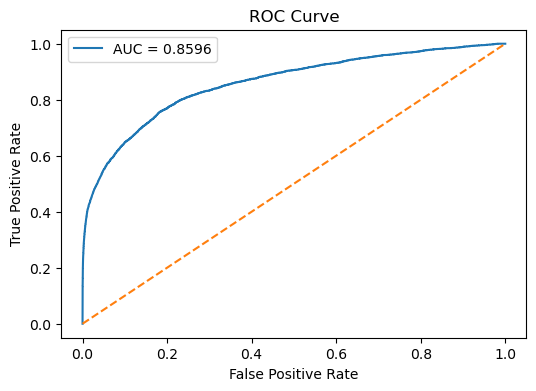

In [89]:
results_lr = evaluate_model("Logistic Regression", y_val, y_pred_lr, y_prob_lr)

In [90]:
results_lr

{'Model': 'Logistic Regression',
 'Accuracy': 0.9721356724353981,
 'Precision': 0.8228527607361963,
 'Recall': 0.25961771110573434,
 'F1 Score': 0.39470296119183373,
 'ROC-AUC': 0.8595525727235572,
 'TN': 113744,
 'FP': 231,
 'FN': 1073,
 'TP': 3060}

In [85]:
model_lr_balanced = LogisticRegression(max_iter=3000,
                                   class_weight='balanced',
                                   random_state=27)

In [86]:
model_lr_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=3000, random_state=27)

In [87]:
y_pred_lr_balanced = model_lr_balanced.predict(X_val_scaled)
y_prob_lr_balanced = model_lr_balanced.predict_proba(X_val_scaled)[:, 1]

Evaluation summary for Logistic Regression(with class_weight='balanced') 

Confusion matrix:
 [[94729 19246]
 [ 1063  3070]]

Accuracy : 0.8280472110271955
Precision: 0.1375694568919161
Recall   : 0.7428018388579725
F1 Score : 0.23214488260425725
ROC-AUC  : 0.866216133266201


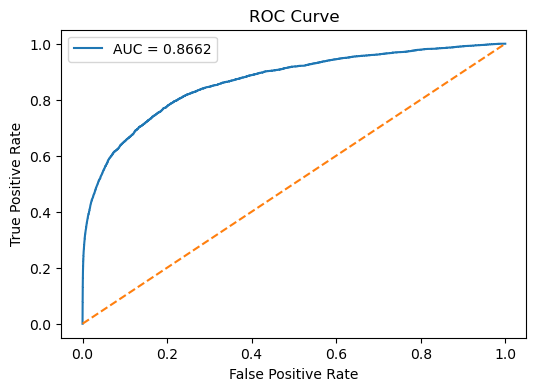

In [91]:
results_lr_balanced = evaluate_model("Logistic Regression(with class_weight='balanced') ", y_val, y_pred_lr_balanced, y_prob_lr_balanced)

The default Logistic Regression model achieved significantly higher precision (82.3%) and F1-score (0.395), but detected only 25.9% of fraudulent transactions. In contrast, the balanced Logistic Regression model achieved a much higher recall (74.3%) and slightly better ROC-AUC (0.8662), at the cost of a large increase in false positives.

This demonstrates the trade-off between precision and recall and how the balanced model is more effective at identifying frauds while the default model is more conservative in raising fraud alerts.

# Random Forest

In [92]:
from sklearn.ensemble import RandomForestClassifier

In [93]:
model_rf = RandomForestClassifier()

model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [94]:
y_pred_rf = model_rf.predict(X_val)
y_prob_rf = model_rf.predict_proba(X_val)[:, 1]

Evaluation summary for Random Forest

Confusion matrix:
 [[113863    112]
 [  2280   1853]]

Accuracy : 0.9797473498831578
Precision: 0.9430025445292621
Recall   : 0.4483426082748609
F1 Score : 0.6077402427025255
ROC-AUC  : 0.9349998713005339


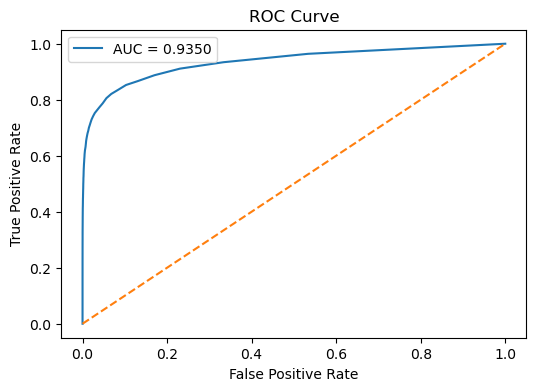

In [95]:
results_rf = evaluate_model("Random Forest", y_val, y_pred_rf, y_prob_rf)

# LightGBM

In [96]:
from lightgbm import LGBMClassifier

In [97]:
for col in X_train.columns:
    if any(ch in str(col) for ch in ['"', '{', '}', '[', ']', ':', ',']):
        print(col)

id_23_IP_PROXY:HIDDEN
id_23_IP_PROXY:TRANSPARENT


In [98]:
X_train = X_train.rename(columns=lambda x: x.replace(':', '_'))
X_val = X_val.rename(columns=lambda x: x.replace(':', '_'))

had to do the above because lightgbm did not accept those feature names, so had to edit them a bit.

In [99]:
lgbm = LGBMClassifier(n_estimators=300,
                      learning_rate=0.05,
                      max_depth=-1,
                      num_leaves=64,
                      subsample=0.8,
                      colsample_bytree=0.8,
                      random_state=27,
                      n_jobs=-1)

lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.290973 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33800
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 517
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101


LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=300,
               n_jobs=-1, num_leaves=64, random_state=27, subsample=0.8)

In [100]:
y_pred_lgbm = lgbm.predict(X_val)
y_prob_lgbm = lgbm.predict_proba(X_val)[:, 1]

Evaluation summary for LightGBM

Confusion matrix:
 [[113808    167]
 [  2006   2127]]

Accuracy : 0.9816015849900092
Precision: 0.9272013949433304
Recall   : 0.5146382772804259
F1 Score : 0.6618951299206473
ROC-AUC  : 0.9522133904019494


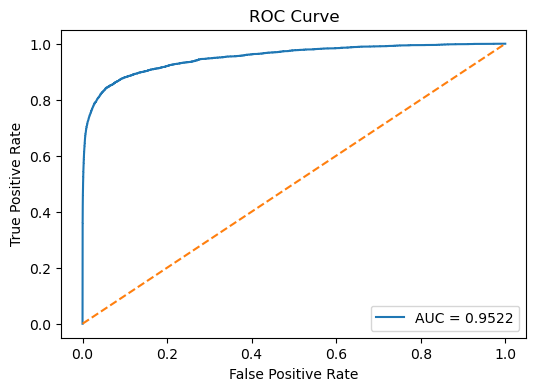

In [101]:
results_lgbm = evaluate_model("LightGBM", y_val, y_pred_lgbm, y_prob_lgbm)

In [102]:
lgbm_balanced = LGBMClassifier(n_estimators=300,
                               learning_rate=0.05,
                               max_depth=-1,
                               num_leaves=64,
                               class_weight='balanced',
                               subsample=0.8,
                               colsample_bytree=0.8,
                               random_state=27,
                               n_jobs=-1)

lgbm_balanced.fit(X_train, y_train)

y_pred_lgbm_bal = lgbm_balanced.predict(X_val)
y_prob_lgbm_bal = lgbm_balanced.predict_proba(X_val)[:, 1]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.324610 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33800
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 517
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


Evaluation summary for LightGBM(with class_weight='balanced')

Confusion matrix:
 [[105721   8254]
 [   649   3484]]

Accuracy : 0.9246198394689606
Precision: 0.29681376725166125
Recall   : 0.8429712073554319
F1 Score : 0.43903975804927226
ROC-AUC  : 0.9527382676903255


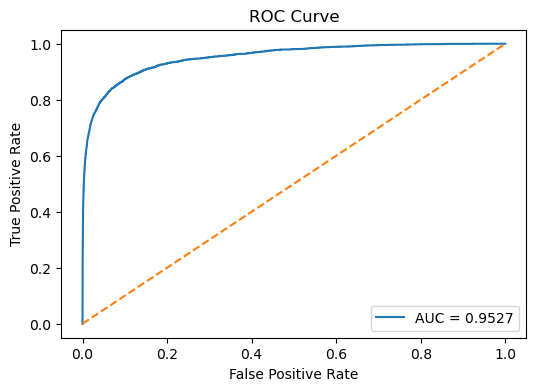

In [103]:
results_lgbm_balanced = evaluate_model("LightGBM(with class_weight='balanced')", y_val, y_pred_lgbm_bal, y_prob_lgbm_bal)

# XGboost

In [104]:
from xgboost import XGBClassifier

In [105]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

In [106]:
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,  # IMPORTANT (neg/pos ratio)
    eval_metric='aucpr',     # better than auc for fraud
    random_state=27,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, ...)

In [107]:
y_pred_xgb = xgb.predict(X_val)
y_prob_xgb = xgb.predict_proba(X_val)[:,1]

Evaluation summary for XGboost

Confusion matrix:
 [[104607   9368]
 [   704   3429]]

Accuracy : 0.9147221187387815
Precision: 0.2679534265843557
Recall   : 0.8296636825550447
F1 Score : 0.40507974010632014
ROC-AUC  : 0.9429470797878843


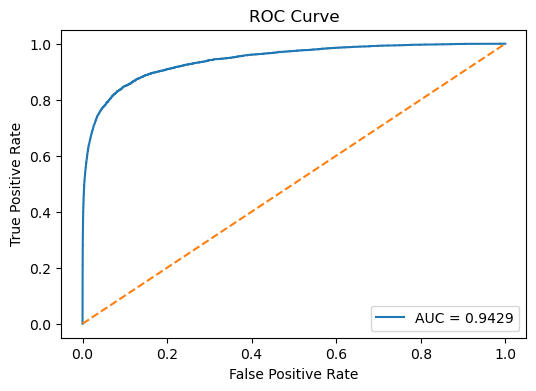

In [108]:
results_xgb = evaluate_model("XGboost", y_val, y_pred_xgb, y_prob_xgb)

So from here, we conclude that lgbm is our best model, whether we want a model which is aggresive toward predicting a fraud(use the parameter class_weight='balanced') or we want a conservative model, both the times, the ROC-AUC score of lighbgm is better than any other model.

So we will try tuning it a little bit.

Threshold tuning for lgbm_balanced. We can get optimal threshold for calssification based on the target recall usign the following cell.

### Threshold tuning for lgbm_balanced model(on recall)

In [124]:
y_proba = lgbm_balanced.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.01, 0.99, 0.01)

target_recall = 0.85  # you can change this

best_thresh = 0
best_precision = 0

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    
    if recall >= target_recall and precision > best_precision:
        best_precision = precision
        best_thresh = t

print("Best Threshold:", best_thresh)
print("Precision:", best_precision)

Best Threshold: 0.48000000000000004
Precision: 0.2795895641107222


In [125]:
y_pred = (y_proba >= best_thresh).astype(int)

Evaluation summary for LightGBM(threshold tuned)

Confusion matrix:
 [[104918   9057]
 [   618   3515]]

Accuracy : 0.9180834490466353
Precision: 0.2795895641107222
Recall   : 0.8504718122429228
F1 Score : 0.420832086201736
ROC-AUC  : 0.9527382676903255


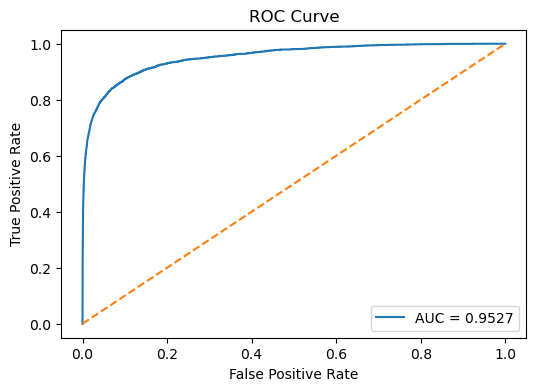

In [126]:
results_lgbm_balanced_threshold_tuned = evaluate_model("LightGBM(threshold tuned)", y_val, y_pred, y_proba)

It performs at least as good as any previous model and we also have a fexibility to change the target recall in this.

# Results

In [127]:
result = pd.DataFrame([results_lr, results_lr_balanced, results_rf, results_lgbm, results_lgbm_balanced, results_xgb, results_lgbm_balanced_threshold_tuned])

In [128]:
result

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,TN,FP,FN,TP
0,Logistic Regression,0.972136,0.822853,0.259618,0.394703,0.859553,113744,231,1073,3060
1,Logistic Regression(with class_weight='balance...,0.828047,0.137569,0.742802,0.232145,0.866216,94729,19246,3070,1063
2,Random Forest,0.979747,0.943003,0.448343,0.607740,0.935000,113863,112,1853,2280
3,LightGBM,0.981602,0.927201,0.514638,0.661895,0.952213,113808,167,2127,2006
4,LightGBM(with class_weight='balanced'),0.924620,0.296814,0.842971,0.439040,0.952738,105721,8254,3484,649
5,XGboost,0.914722,0.267953,0.829664,0.405080,0.942947,104607,9368,3429,704
6,LightGBM(threshold tuned),0.918083,0.279590,0.850472,0.420832,0.952738,104918,9057,3515,618


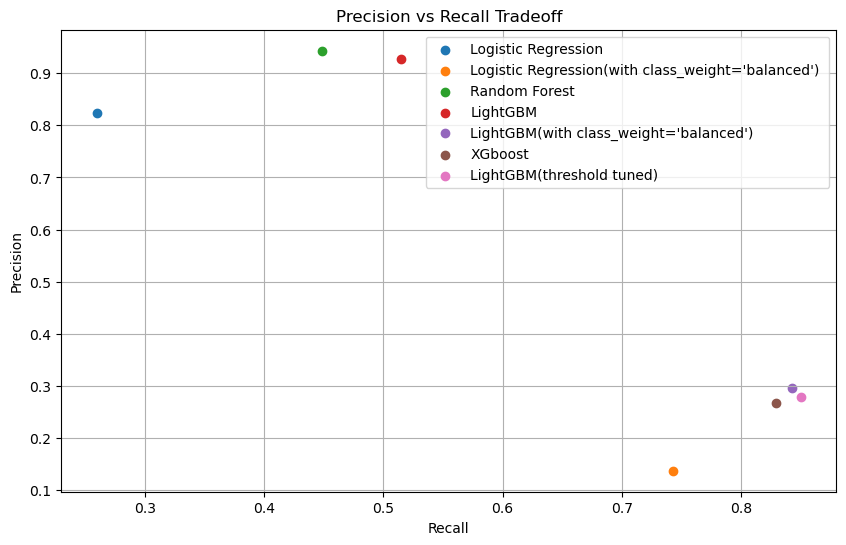

In [145]:
plt.figure(figsize=(10,6))

for i, txt in enumerate(result["Model"]):
    plt.scatter(result["Recall"][i], result["Precision"][i], label=txt)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall Tradeoff")
plt.legend()
plt.grid(True)
plt.show()

# Conclusion

Model selection in fraud detection depends strongly on the business objective. A more aggressive model improves fraud capture (recall) but increases false positives, while a conservative model improves precision at the cost of missing fraud cases. In this project, LightGBM provided the best balance after threshold tuning, making it the most suitable final model.

Future improvements could focus on feature engineering, especially deriving temporal and behavioral features, which are likely to further improve model performance.